# E64 · Population pharmacokinetics: hierarchical compartment models, a mirror-image posterior, and choosing a dose

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real, two classic population-PK datasets. **Theophylline**: 12 subjects, one oral dose, a pre-dose sample and 10 serum samples over 25 h (Boeckmann, Sheiner & Beal 1994; R `datasets::Theoph`). **Warfarin**: 32 subjects, one oral dose of 1.5 mg/kg, plasma concentrations and prothrombin complex activity for 6 days, with weight, age and sex (O'Reilly et al. 1963, 1968; R `nlmixr2data::warfarin`) |
| **You will learn** | The **one-compartment model with first-order absorption** and its closed-form solution · a **hierarchical (population) model**: log-normal clearance, volume and absorption rate with an **LKJ correlation** between subjects · **flip-flop kinetics**: why a single oral dose cannot tell absorption from elimination, the exact mirror-image posterior it creates, and what multi-start chains show that one clean run hides · two fixes: an **ordering constraint** ($k_a > k_e$) and a **physiological prior** on the volume, and when each is wrong · **combined proportional + additive error**, compared by LOO · **normalised prediction errors** as a population-PK residual check · **covariates**: allometric weight scaling with estimated exponents, and what they say about mg/kg dosing · **censored (below-quantification) samples** · a **lag time** that creates a spurious mode, and why · a **turnover (indirect-response) PK/PD model** solved as a convolution, no ODE solver · a **visual predictive check** · **Bayesian therapeutic drug monitoring**: population prediction vs the individual posterior after two blood samples, validated subject by subject · **probability of target attainment** and of toxicity for candidate regimens |

## From a blood sample to a dose

A drug's effect depends on its concentration where it acts, and for most drugs that tracks the
concentration in plasma. **Pharmacokinetics** (PK) describes how a dose becomes a concentration
over time: absorption from the gut, distribution into a volume of body water and tissue, and
elimination by the liver and kidneys. Patients differ, sometimes by a factor of two or three in
how fast they clear a drug, so one dose does not fit all. **Population PK** estimates both the
typical patient and how patients vary, from a few samples per person, and is the standard tool
of drug development and dose selection (Sheiner & Beal's NONMEM, 1980s onwards). It is a
nonlinear hierarchical model: a Bayesian treatment is natural and increasingly common.

This notebook builds a population-PK model on **theophylline** (a bronchodilator with a
narrow therapeutic range, classically 10-20 mg/L with toxicity above 20 mg/L; some current
guidelines aim lower, 5-15 mg/L), meets the classic
identifiability trap of oral dosing, adds covariates, censoring and a pharmacodynamic model on
**warfarin**, and ends with the clinical question: *what dose should this patient get, and how
much do two blood samples change the answer?*

## The plan

1. The theophylline data and the one-compartment model
2. Flip-flop: the same curve from two different bodies
3. Fixing it: an ordering constraint and a physiological prior
4. The population model: prior predictive, fit, diagnostics
5. Checking the fit: error models, individual curves, normalised prediction errors
6. Warfarin: covariates, allometry and a censored sample
7. A little PK/PD: warfarin's effect on clotting as a turnover model
8. Bayesian therapeutic drug monitoring: two samples, validated on every subject
9. The decision: which regimen for this patient?

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import nutpie
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from scipy.stats import norm

from IPython.display import display

from pymc_challenges import data

RANDOM_SEED = 64
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner each
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")  # NaN r_hat of constants
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")


def q(x, probs=(0.05, 0.5, 0.95), axis=None):
    """Posterior quantiles of draws, rounded for printing."""
    return np.round(np.quantile(x, probs, axis=axis), 3)


def fit_report(idata, name):
    """One-line convergence summary: divergences, worst r_hat, smallest bulk ESS."""
    post = idata.posterior.to_dataset()
    keep = [v for v in post.data_vars if not v.endswith("_corr")]  # constant diagonal -> NaN
    rhat = az.rhat(post[keep]).to_dataarray().max().item()
    ess = az.ess(post[keep]).to_dataarray().min().item()
    print(f"{name}: {int(idata.sample_stats['diverging'].sum())} divergences, "
          f"max r_hat {rhat:.3f}, min bulk ESS {ess:.0f}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## 1 · Theophylline: twelve people, one dose each

Each subject swallowed one dose (3-6 mg per kg of body weight) and gave a blood sample just
before it and 10 more over the next 25 hours.

In [2]:
data.describe("theoph")
th_raw = data.load("theoph")
th_raw.head()

theoph: Serum theophylline concentration (conc, mg/L) in 12 subjects after a single oral dose (Dose, mg/kg, 3.1-5.9), 11 samples each over 25 h (Time, h since dosing; 132 rows), with body weight (Wt, kg). Some pre-dose (Time 0) samples are above zero.
  source: Theophylline pharmacokinetics from Boeckmann, Sheiner & Beal (1994), NONMEM Users Guide Part V; R package `datasets` (GPL-2 | GPL-3, part of R), via Rdatasets. Also in Pinheiro & Bates (2000).
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/datasets/Theoph.csv


,Subject,Wt,Dose,Time,conc
rownames,,,,,
1,1,79.6,4.02,0.00,0.74
2,1,79.6,4.02,0.25,2.84
3,1,79.6,4.02,0.57,6.57
4,1,79.6,4.02,1.12,10.50
5,1,79.6,4.02,2.02,9.66


In [3]:
c_pre = th_raw[th_raw.Time == 0].set_index("Subject").conc.sort_index().to_numpy()
th = th_raw[th_raw.Time > 0].reset_index(drop=True)
S = th.Subject.nunique()
sid = th.Subject.to_numpy() - 1
t_obs = th.Time.to_numpy()
y_obs = th.conc.to_numpy()
per_subj = th.groupby("Subject").agg(wt=("Wt", "first"), dose=("Dose", "first"), cmax=("conc", "max"))
per_subj["tmax"] = th.loc[th.groupby("Subject").conc.idxmax(), "Time"].to_numpy()
dose_kg = per_subj.dose.to_numpy()
wt_th = per_subj.wt.to_numpy()
per_subj["pre-dose conc"] = c_pre
print(f"{S} subjects, {len(th)} post-dose samples; pre-dose concentration above 0 in "
      f"{(c_pre > 0).sum()} subjects (max {c_pre.max()} mg/L)")
per_subj.T.round(2)

12 subjects, 120 post-dose samples; pre-dose concentration above 0 in 3 subjects (max 0.74 mg/L)


Subject,1,2,3,4,5,6,7,8,9,10,11,12
wt,79.60,72.40,70.50,72.70,54.60,80.00,64.60,70.50,86.40,58.20,65.00,60.50
dose,4.02,4.40,4.53,4.40,5.86,4.00,4.95,4.53,3.10,5.50,4.92,5.30
cmax,10.50,8.33,8.20,8.60,11.40,6.44,7.09,7.56,9.03,10.21,8.00,9.75
tmax,1.12,1.92,1.02,1.07,1.00,1.15,3.48,2.02,0.63,3.55,0.98,3.52
pre-dose conc,0.74,0.00,0.00,0.00,0.00,0.00,0.15,0.00,0.00,0.24,0.00,0.00


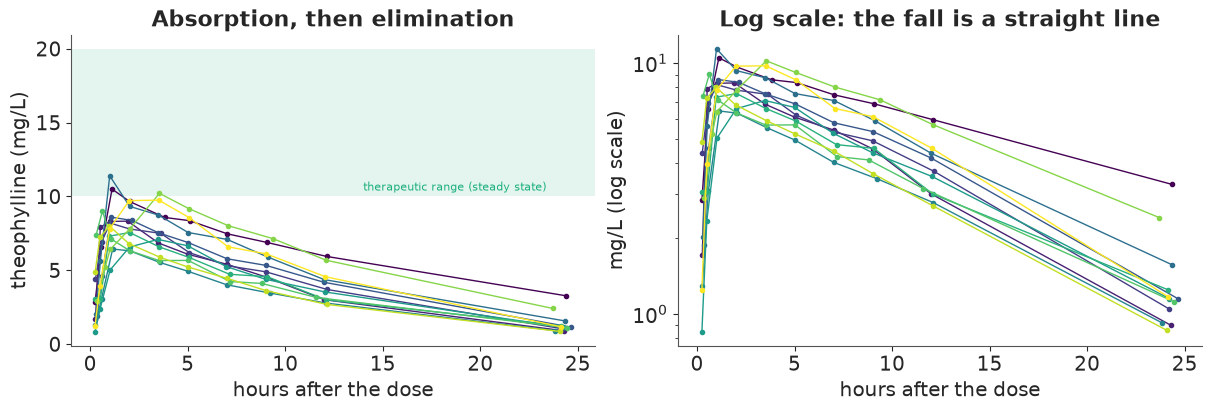

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cmap = plt.get_cmap("viridis")
for k in range(S):
    r = sid == k
    col = cmap(k / (S - 1))
    for ax in axes:
        ax.plot(t_obs[r], y_obs[r], "o-", ms=3, lw=1, color=col)
axes[0].axhspan(10, 20, color=AQUA, alpha=0.12, lw=0)
axes[0].text(14, 10.4, "therapeutic range (steady state)", fontsize=8, color=AQUA)
axes[0].set(xlabel="hours after the dose", ylabel="theophylline (mg/L)",
            title="Absorption, then elimination")
axes[1].set_yscale("log")
axes[1].set(xlabel="hours after the dose", ylabel="mg/L (log scale)",
            title="Log scale: the fall is a straight line");

Concentrations peak within about 0.5-3.5 hours and then fall along nearly straight lines on the
log scale, with slopes that differ between people. Three subjects had a little theophylline in
their blood before the dose (the largest 0.74 mg/L), left over from earlier use; we keep it in
the model as a known amount that decays with the subject's own elimination rate.

**The one-compartment model.** Think of the body as one well-mixed volume $V$ (litres per kg
here, because doses are per kg) that the drug enters from the gut at rate $k_a A_\text{gut}$ and
leaves at rate $k_e C V$. Two linear ODEs with the closed-form solution

$$C(t) = \frac{D\,k_a}{V\,(k_a - k_e)}\left(e^{-k_e t} - e^{-k_a t}\right) + C_\text{pre}\,e^{-k_e t},
\qquad k_e = \frac{CL}{V},$$

where $CL$ is the **clearance** (volume of plasma cleared of drug per hour, per kg). $CL$ and
$V$ are "apparent" values, $CL/F$ and $V/F$, because the absorbed fraction $F$ of an oral dose
is unknown. Clearance is the parameter that sets exposure: the area under the curve is
$\mathrm{AUC} = D / CL$, and at steady state the average concentration is dose rate / $CL$.

The expression has a removable 0/0 at $k_a = k_e$. Writing
$\frac{e^{-k_e t} - e^{-k_a t}}{k_a - k_e} = e^{-k_e t}\,\frac{-\mathrm{expm1}(-\delta t)}{\delta}$
with $\delta = k_a - k_e$ keeps it accurate for any $\delta \neq 0$, of either sign.

In [5]:
def conc_pt(CL, V, ka, t, dose, c_pre=0.0):
    """One-compartment oral model (PyTensor), valid for ka > ke and ka < ke."""
    ke = CL / V
    delta = ka - ke
    return dose * ka / V * pt.exp(-ke * t) * (-pt.expm1(-delta * t)) / delta + c_pre * pt.exp(-ke * t)


def conc_np(CL, V, ka, t, dose, c_pre=0.0):
    """Same model in NumPy, for predictions from posterior draws."""
    ke = CL / V
    delta = ka - ke
    return dose * ka / V * np.exp(-ke * t) * (-np.expm1(-delta * t)) / delta + c_pre * np.exp(-ke * t)

## 2 · Flip-flop: the same curve from two different bodies

Swap the two rates, $k_a \leftrightarrow k_e$, in the formula above. The bracket changes sign
and so does the denominator, so the curve keeps its shape; only the prefactor changes, from
$k_a / V$ to $k_e / V'$. Choose $V' = V k_e / k_a$ and the curves are **identical at every
time**. The mirror patient absorbs slowly and eliminates fast, with a much smaller volume, and
the same clearance ($CL' = V' k_a = V k_e = CL$). After a single oral dose nothing in the data
can tell the two apart: the rise is governed by the faster of the two rates and the fall by
the slower, whichever is which. Pharmacologists call slow absorption that masquerades as
elimination **flip-flop kinetics**.

For one subject we can see this directly. For fixed $(k_a, k_e)$ the curve is linear in the
prefactor, so least squares gives the best prefactor in closed form, and we can map the
residual sum of squares over a grid of both rates.

subject 5: best fit ka = 1.47/h, ke = 0.088/h, V = 0.49 L/kg; mirror: ka = 0.088/h, ke = 1.47/h, V = 0.030 L/kg
residual sum of squares: 13.4682 vs mirror 13.4682


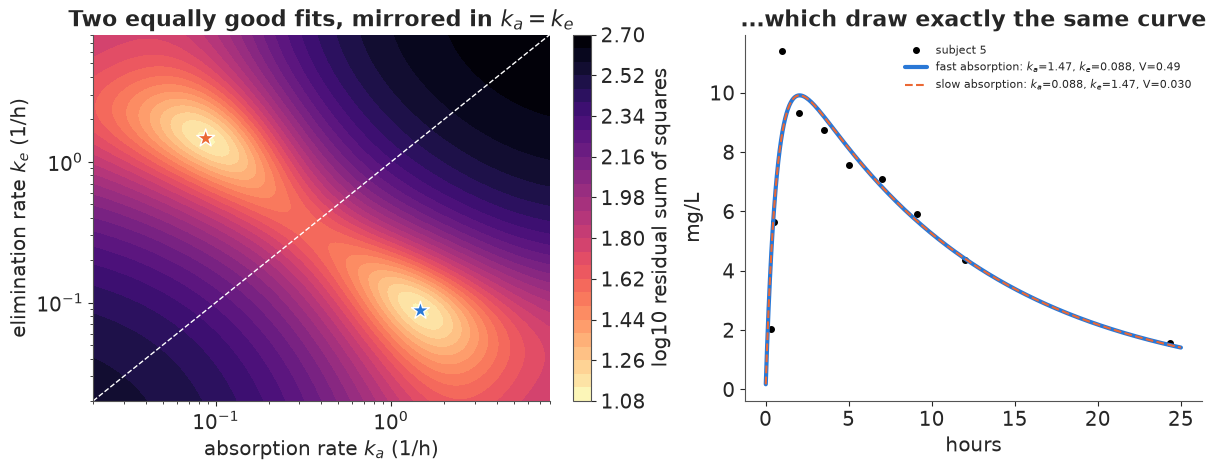

In [6]:
k_demo = 4  # subject 5
r = sid == k_demo
lka = np.linspace(np.log(0.02), np.log(8), 220)
KA, KE = np.meshgrid(np.exp(lka), np.exp(lka))
dlt = KA - KE
dlt = np.where(np.abs(dlt) < 1e-9, 1e-9, dlt)
shape_ = np.exp(-KE[..., None] * t_obs[r]) * -np.expm1(-dlt[..., None] * t_obs[r]) / dlt[..., None]
amp = (shape_ * y_obs[r]).sum(-1) / (shape_ ** 2).sum(-1)  # least-squares prefactor
rss = ((y_obs[r] - amp[..., None] * shape_) ** 2).sum(-1)
i_best = np.unravel_index(np.argmin(np.where(KA > KE, rss, np.inf)), rss.shape)
ka_hat, ke_hat = KA[i_best], KE[i_best]
V_hat = dose_kg[k_demo] * ka_hat / amp[i_best]  # the prefactor is D ka / V
print(f"subject {k_demo + 1}: best fit ka = {ka_hat:.2f}/h, ke = {ke_hat:.3f}/h, V = {V_hat:.2f} L/kg; "
      f"mirror: ka = {ke_hat:.3f}/h, ke = {ka_hat:.2f}/h, V = {V_hat * ke_hat / ka_hat:.3f} L/kg")
print(f"residual sum of squares: {rss[i_best]:.4f} vs mirror {rss[i_best[1], i_best[0]]:.4f}")

tg = np.linspace(0.01, 25, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
cs = axes[0].contourf(KA, KE, np.log10(rss), levels=25, cmap="magma_r")
fig.colorbar(cs, ax=axes[0], label="log10 residual sum of squares")
axes[0].plot([0.02, 8], [0.02, 8], color="w", lw=1, ls="--")
axes[0].scatter([ka_hat, ke_hat], [ke_hat, ka_hat], marker="*", s=180, c=[BLUE, ORANGE],
                edgecolor="w", zorder=5)
axes[0].set(xscale="log", yscale="log", xlabel="absorption rate $k_a$ (1/h)",
            ylabel="elimination rate $k_e$ (1/h)", title="Two equally good fits, mirrored in $k_a = k_e$")
axes[1].plot(t_obs[r], y_obs[r], "ko", ms=4, label=f"subject {k_demo + 1}")
axes[1].plot(tg, conc_np(V_hat * ke_hat, V_hat, ka_hat, tg, dose_kg[k_demo]), color=BLUE, lw=3,
             label=f"fast absorption: $k_a$={ka_hat:.2f}, $k_e$={ke_hat:.3f}, V={V_hat:.2f}")
V_m = V_hat * ke_hat / ka_hat
axes[1].plot(tg, conc_np(V_m * ka_hat, V_m, ke_hat, tg, dose_kg[k_demo]), color=ORANGE, lw=1.5, ls="--",
             label=f"slow absorption: $k_a$={ke_hat:.3f}, $k_e$={ka_hat:.2f}, V={V_m:.3f}")
axes[1].set(xlabel="hours", ylabel="mg/L", title="...which draw exactly the same curve")
axes[1].legend(fontsize=8);

The error surface is exactly symmetric about the diagonal. Each subject has two best fits, and
the mirror one needs a volume of about 0.03 L/kg (2 L for a 70 kg adult), less than the volume of
blood plasma. So the data cannot choose, but physiology can.

**What does a sampler do with this?** In a hierarchical model the whole population can flip
together, because the map $(\log CL, \log V, \log k_a) \mapsto (\log CL,\ \log CL - \log k_a,\
\log CL - \log V)$ is linear with unit Jacobian: a multivariate normal population maps to
another multivariate normal population, fitting the data exactly as well. We fit a model that
puts independent vague priors on $\log CL$, $\log V$, $\log k_a$, and start two chains in the
usual place and two in the mirror world. (PyMC's own NUTS sampler, which accepts one starting
point per chain; `cores=2` keeps memory low.)

In [7]:
coords_th = {"subj": np.arange(1, S + 1), "par": ["CL", "V", "ka"]}


def sigma_combined(c, sig_prop, sig_add):
    return pt.sqrt((sig_prop * c) ** 2 + sig_add ** 2)


with pm.Model(coords=coords_th) as m_vague:
    mu = pm.Normal("mu", 0.0, 2.0, dims="par")  # log CL, log V, log ka: vague and unordered
    chol, _, _ = pm.LKJCholeskyCov("L", n=3, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0),
                                   compute_corr=True)
    z = pm.Normal("z", 0.0, 1.0, dims=("subj", "par"))
    theta = mu + z @ chol.T
    CL, V, ka = pt.exp(theta[:, 0]), pt.exp(theta[:, 1]), pt.exp(theta[:, 2])
    c = conc_pt(CL[sid], V[sid], ka[sid], t_obs, dose_kg[sid], c_pre[sid])
    sig_prop = pm.HalfNormal("sig_prop", 0.2)
    sig_add = pm.HalfNormal("sig_add", 0.5)
    pm.Normal("y", c, sigma_combined(c, sig_prop, sig_add), observed=y_obs)

usual = {"mu": np.array([np.log(0.04), np.log(0.5), np.log(1.5)])}
mirror = {"mu": np.array([np.log(0.04), np.log(0.04) - np.log(1.5), np.log(0.04) - np.log(0.5)])}
t0 = time.perf_counter()
with m_vague:
    idata_vague = pm.sample(nuts_sampler="pymc", chains=4, cores=2, initvals=[usual, usual, mirror, mirror],
                            random_seed=RANDOM_SEED, progressbar=False)
    pm.compute_log_likelihood(idata_vague, progressbar=False)
print(f"sampled in {time.perf_counter() - t0:.0f} s")
fit_report(idata_vague, "vague, unordered")
az.summary(idata_vague, var_names=["mu", "sig_prop", "sig_add"], round_to=3)

There were 72 divergences after tuning. Increase `target_accept` or reparameterize.


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


sampled in 9 s
vague, unordered: 72 divergences, max r_hat 1.759, min bulk ESS 6


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[CL],-3.203,0.086,-3.338,-3.068,1496.619,1571.033,1.009,0.002,0.002
mu[V],-2.188,1.432,-3.904,-0.711,6.169,44.230,1.733,0.708,0.005
mu[ka],-1.005,1.443,-2.509,0.711,6.130,35.274,1.734,0.714,0.004
sig_prop,0.072,0.033,0.016,0.125,1494.849,1443.894,1.004,0.001,0.001
sig_add,0.598,0.120,0.385,0.767,1577.726,1823.318,1.007,0.003,0.002


In [8]:
per_chain = pd.DataFrame({
    "CL (L/h/kg)": np.exp(idata_vague.posterior["mu"].sel(par="CL")).mean("draw").values,
    "V (L/kg)": np.exp(idata_vague.posterior["mu"].sel(par="V")).mean("draw").values,
    "ka (1/h)": np.exp(idata_vague.posterior["mu"].sel(par="ka")).mean("draw").values,
    "log-likelihood": idata_vague.log_likelihood["y"].sum("y_dim_0").mean("draw").values,
    "divergences": idata_vague.sample_stats["diverging"].sum("draw").values,
}, index=pd.Index(["usual", "usual", "mirror", "mirror"], name="chain started at"))
per_chain["ke = CL/V"] = per_chain["CL (L/h/kg)"] / per_chain["V (L/kg)"]
per_chain.round(3)

,CL (L/h/kg),V (L/kg),ka (1/h),log-likelihood,divergences,ke = CL/V
chain started at,,,,,,
usual,0.041,0.464,1.578,-134.371,0,0.088
usual,0.041,0.465,1.582,-134.721,0,0.088
mirror,0.041,0.028,0.087,-135.456,33,1.450
mirror,0.040,0.028,0.088,-135.403,39,1.453


Each chain stays in the world it started in. The typical clearance is the same in all four
(it is identified: $CL = D/\mathrm{AUC}$), and the data fit equally well (average
log-likelihoods within about 1). All the divergences come from the mirror chains, whose
population has to squeeze into very small volumes. And the mirror chains describe a population with a volume of
0.03 L/kg and an absorption rate that equals the usual chains' elimination rate. r_hat on
$\mu_V$ and $\mu_{k_a}$ is far above 1, which is the right alarm. The unsettling part: **a
single run that happened to start in one basin would look perfectly healthy**. Default nutpie
starts near $\log k_a = \log V = \log CL = 0$, i.e. $k_a = k_e$ on the ridge between the two
basins; which way each chain rolls depends on the data, the units and the random jitter.

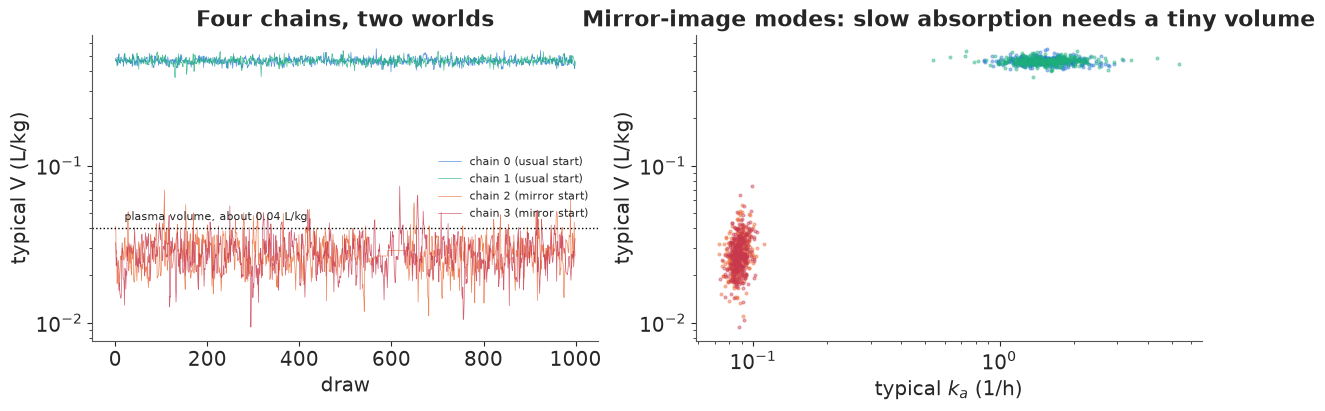

In [9]:
mu_post = idata_vague.posterior["mu"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ch, col in zip(range(4), [BLUE, AQUA, ORANGE, RED]):
    axes[0].plot(np.exp(mu_post.sel(chain=ch, par="V")), lw=0.5, color=col, alpha=0.8,
                 label=f"chain {ch} ({per_chain.index[ch]} start)")
    axes[1].scatter(np.exp(mu_post.sel(chain=ch, par="ka"))[::3], np.exp(mu_post.sel(chain=ch, par="V"))[::3],
                    s=4, alpha=0.4, color=col)
axes[0].legend(fontsize=8, markerscale=3, loc="center right")
axes[0].axhline(0.04, color="k", ls=":", lw=1)
axes[0].text(20, 0.045, "plasma volume, about 0.04 L/kg", fontsize=8)
axes[0].set(yscale="log", xlabel="draw", ylabel="typical V (L/kg)", title="Four chains, two worlds")
axes[1].set(xscale="log", yscale="log", xlabel="typical $k_a$ (1/h)", ylabel="typical V (L/kg)",
            title="Mirror-image modes: slow absorption needs a tiny volume");

## 3 · Fixing it: an ordering constraint and a physiological prior

Two kinds of information break the symmetry, and they encode different assumptions.

1. **Ordering: $k_a > k_e$.** Parameterise the absorption rate as $k_a = k_e + \exp(\eta)$, so
   only the "absorption faster than elimination" branch exists. True for an immediate-release
   oral solution like this one; **false** for sustained-release tablets, depots and many
   subcutaneous biologics, where absorption *is* the slow step and true flip-flop kinetics
   occurs. There the ordering would silently pick the wrong world.
2. **A physiological prior on $V$.** Theophylline distributes in total body water, about
   0.5 L/kg in adults (textbook values 0.3-0.7), and no drug's volume can be smaller than plasma
   (0.04 L/kg). A LogNormal(log 0.5, 0.3) prior on the typical volume puts the mirror mode at
   $\log(0.5/0.03)/0.3 \approx 9$ prior standard deviations: it simply disappears. This works for
   sustained release too, because it does not assume which rate is faster.

We use both, plus weakly informative priors from the same textbook knowledge: typical
theophylline clearance about 0.04 L/h/kg in adult non-smokers (LogNormal(log 0.04, 0.5) covers
0.015-0.1), and an absorption excess $k_a - k_e$ around 1.5/h with a wide prior. Between-subject
standard deviations on the log scale get HalfNormal(0.5) (coefficients of variation up to about
100%), with an LKJ(2) prior on their correlations. Parameters are **non-centred**
($\theta_i = \mu + L z_i$), as usual for a dozen groups.

In [10]:
MU_PRIOR = np.array([np.log(0.04), np.log(0.5), np.log(1.5)])
SD_PRIOR = np.array([0.5, 0.3, 1.0])
coords_pop = {"subj": np.arange(1, S + 1), "par": ["CL", "V", "ka_excess"]}


def build_theoph(error="combined", mask=False, ghost=False):
    """Population model. mask: likelihood weights as pm.Data (for held-out fits);
    ghost: one extra subject with no data, i.e. a new patient from the population."""
    coords = dict(coords_pop, subj=np.arange(1, S + 1 + ghost))
    with pm.Model(coords=coords) as m:
        mu = pm.Normal("mu", MU_PRIOR, SD_PRIOR, dims="par")
        chol, _, _ = pm.LKJCholeskyCov("L", n=3, eta=2.0, sd_dist=pm.HalfNormal.dist(0.5),
                                       compute_corr=True)
        z = pm.Normal("z", 0.0, 1.0, dims=("subj", "par"))
        theta = mu + z @ chol.T
        CL = pm.Deterministic("CL", pt.exp(theta[:, 0]), dims="subj")
        V = pm.Deterministic("V", pt.exp(theta[:, 1]), dims="subj")
        ka = pm.Deterministic("ka", CL / V + pt.exp(theta[:, 2]), dims="subj")  # ka > ke by construction
        c = conc_pt(CL[sid], V[sid], ka[sid], t_obs, dose_kg[sid], c_pre[sid])
        if error == "combined":
            sig = sigma_combined(c, pm.HalfNormal("sig_prop", 0.2), pm.HalfNormal("sig_add", 0.5))
        elif error == "proportional":
            sig = pm.HalfNormal("sig_prop", 0.2) * c
        else:
            sig = pm.HalfNormal("sig_add", 0.5) * pt.ones_like(c)
        if mask:
            w = pm.Data("w", np.ones(len(y_obs)))
            pm.Potential("loglik", (w * pm.logp(pm.Normal.dist(c, sig), y_obs)).sum())
        else:
            pm.Normal("y", c, sig, observed=y_obs)
    return m


m_pop = build_theoph()
with m_pop:
    prior_pop = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)

## 4 · The population model: prior predictive, fit, diagnostics

Before fitting: what concentration curves do these priors imply for a 4.5 mg/kg dose?

prior predictive peak concentration, 5/50/95%: [ 3.032  7.406 17.024]
prior predictive time of peak (h), 5/50/95%: [0.552 1.931 6.576]


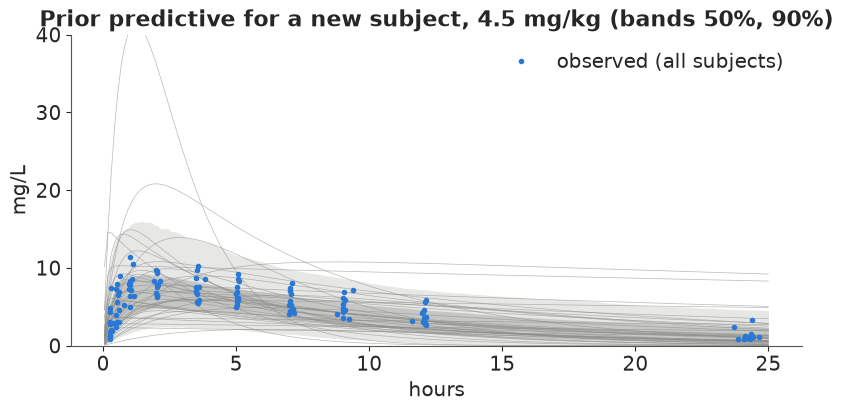

In [11]:
pr = prior_pop.prior
tg = np.linspace(0.05, 25, 200)
prior_curves = conc_np(pr["CL"].values[0, :, 0, None], pr["V"].values[0, :, 0, None],
                       pr["ka"].values[0, :, 0, None], tg, 4.5)
fig, ax = plt.subplots(figsize=(8, 4))
for lo, hi, a in [(0.05, 0.95, 0.2), (0.25, 0.75, 0.35)]:
    ax.fill_between(tg, *np.quantile(prior_curves, [lo, hi], axis=0), color=GREY, alpha=a, lw=0)
ax.plot(tg, prior_curves[:40].T, color=GREY, lw=0.5, alpha=0.6)
ax.plot(t_obs, y_obs, "o", ms=3, color=BLUE, label="observed (all subjects)")
ax.set(ylim=(0, 40), xlabel="hours", ylabel="mg/L",
       title="Prior predictive for a new subject, 4.5 mg/kg (bands 50%, 90%)")
ax.legend()
print("prior predictive peak concentration, 5/50/95%:", q(prior_curves.max(axis=1)))
print("prior predictive time of peak (h), 5/50/95%:", q(tg[prior_curves.argmax(axis=1)]))

The priors allow peaks from about 3 to 17 mg/L and times to peak from half an hour to six and a
half hours: they rule out absurd bodies (and the mirror world) without deciding the answer.

In [12]:
t0 = time.perf_counter()
with m_pop:
    idata_pop = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    pm.compute_log_likelihood(idata_pop, progressbar=False)
print(f"sampled in {time.perf_counter() - t0:.0f} s (nutpie, "
      f"{idata_pop.posterior.attrs.get('tuning_steps')} warm-up steps)")
fit_report(idata_pop, "population model")
az.summary(idata_pop, var_names=["mu", "L_stds", "sig_prop", "sig_add"], ci_prob=0.9, round_to=3)

sampled in 4 s (nutpie, 400 warm-up steps)
population model: 0 divergences, max r_hat 1.005, min bulk ESS 684


,mean,sd,eti90_lb,eti90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[CL],-3.205,0.087,-3.344,-3.061,1668.294,2135.173,1.001,0.002,0.002
mu[V],-0.767,0.048,-0.845,-0.687,2320.991,2386.878,1.003,0.001,0.001
mu[ka_excess],0.350,0.225,-0.024,0.719,1506.673,1831.238,1.005,0.006,0.005
L_stds[0],0.278,0.075,0.179,0.412,2194.825,2339.451,1.001,0.002,0.002
L_stds[1],0.133,0.045,0.072,0.217,2576.902,2269.316,1.001,0.001,0.001
L_stds[2],0.750,0.163,0.518,1.041,2090.550,2367.307,1.003,0.004,0.003
sig_prop,0.075,0.033,0.015,0.128,1735.077,1193.967,1.003,0.001,0.001
sig_add,0.586,0.123,0.366,0.765,2101.108,1889.570,1.001,0.003,0.003


In [13]:
post_mu = az.extract(idata_pop, var_names=["mu"]).values
corr = az.extract(idata_pop, var_names=["L_corr"]).values
sds = az.extract(idata_pop, var_names=["L_stds"]).values
typ = pd.DataFrame({
    "typical CL (L/h/kg)": q(np.exp(post_mu[0])),
    "typical V (L/kg)": q(np.exp(post_mu[1])),
    "typical ka (1/h)": q(np.exp(post_mu[0] - post_mu[1]) + np.exp(post_mu[2])),
    "half-life (h)": q(np.log(2) * np.exp(post_mu[1] - post_mu[0])),
    "between-subject CV of CL": q(np.sqrt(np.expm1(sds[0] ** 2))),
    "corr(log CL, log V)": q(corr[0, 1]),
}, index=["5%", "50%", "95%"]).T
typ

,5%,50%,95%
typical CL (L/h/kg),0.035,0.040,0.047
typical V (L/kg),0.430,0.464,0.503
typical ka (1/h),1.065,1.504,2.139
half-life (h),6.893,7.941,9.116
between-subject CV of CL,0.180,0.272,0.430
"corr(log CL, log V)",0.042,0.600,0.897


Clean sampling in 3 seconds: no divergences, r_hat at most 1.005, bulk ESS above 680 for every
parameter. The typical subject clears 0.040 L/h per kg with a volume of 0.46 L/kg, so the
half-life is about 8 hours, close to textbook values for adult non-smokers. Clearance varies
between people by about 27% (coefficient of variation), the volume by about half that, and
absorption a lot (log-scale sd 0.75). The correlation between clearance and volume is probably
positive (median 0.6), but with 12 people its 90% interval runs from 0.04 to 0.90.

The data identified the typical values well: the prior's 90% interval for the typical
clearance was 0.018-0.091 L/h/kg, the posterior's is 0.035-0.047.

## 5 · Checking the fit

**Error model.** Assay errors are often proportional to the concentration plus a floor near the
quantification limit. We fitted both terms; LOO compares that with the additive error alone.

In [14]:
loo_err = {"combined": az.loo(idata_pop)}
for err in ["additive"]:
    with build_theoph(error=err):
        idt = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
        pm.compute_log_likelihood(idt, progressbar=False)
    fit_report(idt, err)
    loo_err[err] = az.loo(idt)
    del idt
az.compare(loo_err, round_to=1)

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


additive: 0 divergences, max r_hat 1.011, min bulk ESS 650


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
additive,0,0.0,0.0,NaN,,6 k̂ > 0.70,35.4,-158.3,16.4,0.6
combined,1,-0.4,3.1,0.6,|elpd_diff| < 4,7 k̂ > 0.70,36.5,-158.7,16.4,0.4


The two error models differ by 0.4 in expected log predictive density with a standard error of
3.1: 120 concentrations between 0.85 and 11 mg/L do not decide the question (and 6-7
observations have Pareto $\hat k > 0.7$ in each model, so the LOO numbers are themselves
approximate). We keep the combined model, which contains the additive one and matters when we
extrapolate to steady-state concentrations twice as high as anything observed here. Its
proportional part is about 8% (though its interval reaches from 2% to 13%) and its additive part
about 0.6 mg/L.

**Individual fits.** Each panel shows one subject's posterior (dark band: the curve, 90%;
light band: a new measurement, 90%), and in grey what the *population* would have predicted for
a new person with that dose. The gap between grey and blue is what the subject's own data taught
the model.

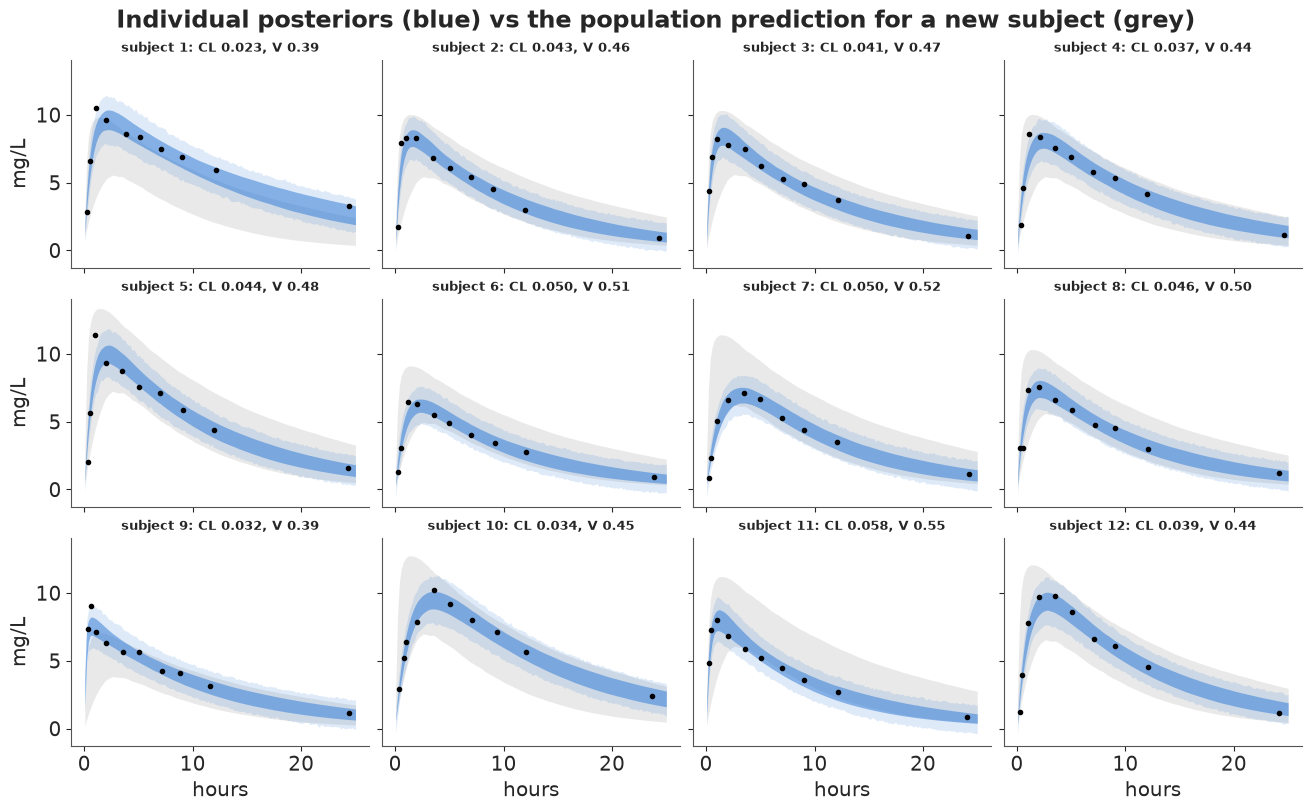

In [15]:
dr = az.extract(idata_pop, var_names=["CL", "V", "ka", "sig_prop", "sig_add", "mu", "L_stds", "L_corr"],
                num_samples=1000, random_seed=RANDOM_SEED)
CLd, Vd, kad = (dr[v].values for v in ["CL", "V", "ka"])  # (subj, draw)
spd, sad = dr["sig_prop"].values, dr["sig_add"].values
# a brand-new subject from the population, per posterior draw: eta ~ MvNormal(0, diag(s) R diag(s))
s_d = dr["L_stds"].values.T                                   # (draw, 3)
cov_d = s_d[:, :, None] * np.moveaxis(dr["L_corr"].values, -1, 0) * s_d[:, None, :]
eta_new = np.einsum("dij,dj->id", np.linalg.cholesky(cov_d), rng.normal(size=(len(s_d), 3)))
th_new = dr["mu"].values + eta_new
CL_new, V_new = np.exp(th_new[0]), np.exp(th_new[1])
ka_new = CL_new / V_new + np.exp(th_new[2])

tg = np.linspace(0.05, 25, 150)
fig, axes = plt.subplots(3, 4, figsize=(13, 8), sharex=True, sharey=True)
for k, ax in enumerate(axes.flat):
    r = sid == k
    cur = conc_np(CLd[k][:, None], Vd[k][:, None], kad[k][:, None], tg, dose_kg[k], c_pre[k])
    ynew = cur + rng.normal(size=cur.shape) * np.sqrt((spd[:, None] * cur) ** 2 + sad[:, None] ** 2)
    pop = conc_np(CL_new[:, None], V_new[:, None], ka_new[:, None], tg, dose_kg[k], c_pre[k])
    ax.fill_between(tg, *np.quantile(pop, [0.05, 0.95], axis=0), color=GREY, alpha=0.18, lw=0)
    ax.fill_between(tg, *np.quantile(ynew, [0.05, 0.95], axis=0), color=BLUE, alpha=0.15, lw=0)
    ax.fill_between(tg, *np.quantile(cur, [0.05, 0.95], axis=0), color=BLUE, alpha=0.5, lw=0)
    ax.plot(t_obs[r], y_obs[r], "ko", ms=3)
    ax.set_title(f"subject {k + 1}: CL {np.median(CLd[k]):.3f}, V {np.median(Vd[k]):.2f}", fontsize=9)
for ax in axes[-1]:
    ax.set_xlabel("hours")
for ax in axes[:, 0]:
    ax.set_ylabel("mg/L")
fig.suptitle("Individual posteriors (blue) vs the population prediction for a new subject (grey)");

From 2 hours on, nearly every sample sits inside its subject's band, whether the rise is fast
(subjects 1, 5, 9) or slow (7, 10, 12). The misses are at the peak: subjects 1, 5 and 9 each
have a sample in the first hour or so at or above the upper edge of the band. A single first-order absorption rate
cannot follow a very sharp early peak, and that is also where a few minutes' error in the
recorded sampling time changes the concentration most. The grey population band is wide:
before seeing a patient's own concentrations, the model can only say their peak will be
somewhere between about 5 and 12 mg/L. That width is the case for measuring.

**Normalised prediction errors.** The population-PK version of a residual plot: for each
observation, where does it fall within its own posterior predictive distribution? Plot the
standard-normal quantile of that probability against time and against the predicted
concentration: no trend and roughly unit spread mean the structural model and the error model
are adequate.

share outside the 90% predictive interval: 0.075 (expect about 0.10); sd of the errors: 0.77


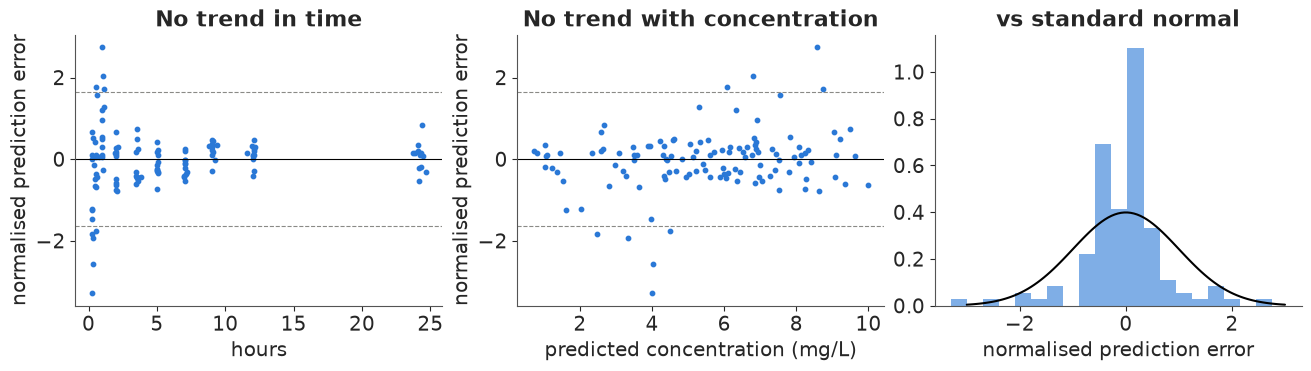

In [16]:
c_obs_d = conc_np(CLd[sid], Vd[sid], kad[sid], t_obs[:, None], dose_kg[sid, None], c_pre[sid, None])
sd_obs_d = np.sqrt((spd * c_obs_d) ** 2 + sad ** 2)
y_rep = c_obs_d + rng.normal(size=c_obs_d.shape) * sd_obs_d
pit = (y_rep < y_obs[:, None]).mean(axis=1).clip(0.5 / y_rep.shape[1], 1 - 0.5 / y_rep.shape[1])
npe = norm.ppf(pit)
pred_med = np.median(c_obs_d, axis=1)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].scatter(t_obs, npe, s=10, c=BLUE)
axes[1].scatter(pred_med, npe, s=10, c=BLUE)
for ax, xl in zip(axes[:2], ["hours", "predicted concentration (mg/L)"]):
    ax.axhline(0, color="k", lw=0.8)
    for s_ in (-1.645, 1.645):
        ax.axhline(s_, color=GREY, ls="--", lw=0.8)
    ax.set(xlabel=xl, ylabel="normalised prediction error")
axes[2].hist(npe, bins=20, density=True, color=BLUE, alpha=0.6)
xx = np.linspace(-3, 3, 100)
axes[2].plot(xx, norm.pdf(xx), color="k")
axes[2].set(xlabel="normalised prediction error", title="vs standard normal")
axes[0].set_title("No trend in time")
axes[1].set_title("No trend with concentration")
print(f"share outside the 90% predictive interval: {(np.abs(npe) > 1.645).mean():.3f} (expect about 0.10); "
      f"sd of the errors: {npe.std():.2f}")

The errors are centred on zero at every time and concentration, with no drift. Their spread
is not constant, though: wide in the first two hours, narrow afterwards. That repeats what the
individual panels showed. The absorption phase is where the model is weakest and where the one
error model is too tight; later samples are predicted more closely than the error model
expects (in-sample checks with 36 subject-level parameters for 120 observations are
optimistic). Overall 7.5% of observations fall outside their 90% interval and the errors have
an sd of 0.77. For the decisions below, which rest on clearance and the elimination phase,
this is adequate; section 8 tests the model out of sample.

## 6 · Warfarin: covariates, allometry and a censored sample

Theophylline doses were already scaled per kg, which hides the question of *how* the body's
parameters scale with size. The warfarin study (32 subjects, 1.5 mg/kg each) records weight,
age and sex, and its sampling is uneven: 13 subjects were sampled in the first hours, the other
19 only from 24 hours on, when absorption is long over.

In [17]:
data.describe("warfarin_pkpd")
wf = data.load("warfarin_pkpd")
ids = np.sort(wf.id.unique())
Sw = len(ids)
pos = {k: i for i, k in enumerate(ids)}
cov = wf.groupby("id").first().loc[ids]
wt = cov.wt.to_numpy()
female = (cov.sex == "female").to_numpy().astype(float)
dose_w = wf[wf.evid == 1].set_index("id").amt.loc[ids].to_numpy()
cp = wf[(wf.dvid == "cp") & (wf.evid == 0)]
pk_i, pk_t, pk_y = cp.id.map(pos).to_numpy(), cp.time.to_numpy(), cp.dv.to_numpy()
pca = wf[wf.dvid == "pca"]
pd_i, pd_t, pd_y = pca.id.map(pos).to_numpy(), pca.time.to_numpy(), pca.dv.to_numpy()
early = cp.groupby("id").time.min().loc[ids] < 24
print(f"{Sw} subjects, {len(cp)} concentrations, {len(pca)} PCA values; sampled before 24 h: "
      f"{early.sum()}; weight {wt.min():.0f}-{wt.max():.0f} kg; {int(female.sum())} women")
print("concentrations reported as 0:", cp[cp.dv == 0][["id", "time"]].to_numpy().tolist(),
      "| smallest positive value:", cp[cp.dv > 0].dv.min())

warfarin_pkpd: Warfarin PK/PD in 32 subjects after one oral dose of 1.5 mg/kg (amt, mg, on the evid = 1 rows). 515 rows: id, time (h, 0-144), amt, dv (plasma warfarin mg/L when dvid = 'cp', 251 samples, four reported as 0 at 0.5 h; prothrombin complex activity, % of normal, when dvid = 'pca', 232 samples), evid, wt (kg, 40-102), age (y, 21-63), sex (27 male, 5 female).
  source: O'Reilly, Aggeler & Leong (1963) J Clin Invest 42:1542 and O'Reilly & Aggeler (1968) Circulation 38:169, as curated by Funaki, Holford & Fujita (2018) in R package `nlmixr2data` (GPL >= 3). CONVERTED from the package's `warfarin.rda` (R serialisation) to CSV, so keep the cached file in data/.
  url:    https://github.com/nlmixr2/nlmixr2data/raw/main/data/warfarin.rda
32 subjects, 251 concentrations, 232 PCA values; sampled before 24 h: 13; weight 40-102 kg; 5 women
concentrations reported as 0: [[1.0, 0.5], [3.0, 0.5], [9.0, 0.5], [15.0, 0.5]] | smallest positive value: 0.6


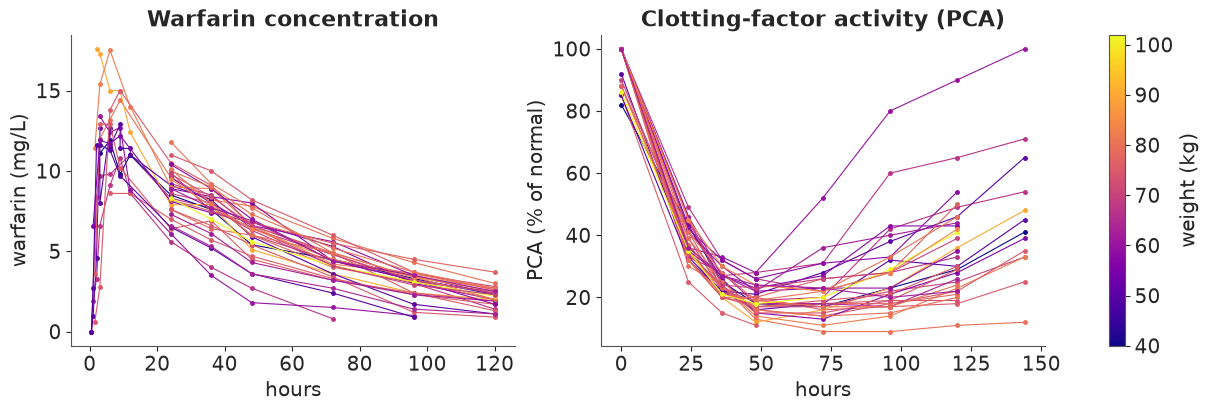

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
norm_w = plt.Normalize(wt.min(), wt.max())
for k in range(Sw):
    col = plt.get_cmap("plasma")(norm_w(wt[k]))
    r1, r2 = pk_i == k, pd_i == k
    axes[0].plot(pk_t[r1], pk_y[r1], "o-", ms=2.5, lw=0.8, color=col)
    axes[1].plot(pd_t[r2], pd_y[r2], "o-", ms=2.5, lw=0.8, color=col)
axes[0].set(xlabel="hours", ylabel="warfarin (mg/L)", title="Warfarin concentration")
axes[1].set(xlabel="hours", ylabel="PCA (% of normal)", title="Clotting-factor activity (PCA)")
fig.colorbar(plt.cm.ScalarMappable(norm=norm_w, cmap="plasma"), ax=axes, label="weight (kg)");

**Allometric scaling.** Across mammals, metabolic rate and hence clearance scale with body mass
to roughly the power 3/4, and volumes with power 1. The population model writes this as a
covariate on the typical values,

$$\log CL_i = \theta_{CL} + b_{CL}\log(\mathrm{wt}_i/70) + \beta_\text{F}\,\mathrm{female}_i + \eta_{CL,i},
\qquad \log V_i = \theta_V + b_V \log(\mathrm{wt}_i/70) + \eta_{V,i},$$

and we **estimate** the exponents with priors centred on theory (Normal(0.75, 0.5) and
Normal(1, 0.5)) rather than fixing them, to see whether 32 people between 40 and 102 kg can
tell. Absorption gets a population lag time (warfarin tablets take a while to dissolve) and
the same ordering as before.

**Censoring.** Four samples at 0.5 h are reported as 0. A concentration is never exactly 0 after
a dose; these are almost certainly below the assay's limit of quantification. The limit is not
reported; the smallest positive value is 0.6 mg/L, so we assume LLOQ = 0.5 mg/L and use the
**censored** likelihood $P(y < \text{LLOQ})$ for those four rows (`pm.Censored` with a lower
bound on those rows only, $-\infty$ elsewhere): a reported 0 says "below the limit", not "zero".

## 7 · A little PK/PD: warfarin's effect on clotting as a turnover model

Warfarin does not act on its target directly: it blocks the **synthesis** of clotting factors,
which then disappear at their own natural turnover rate. So the prothrombin complex activity
(PCA) keeps falling for a day or two after the concentration has peaked, and recovers slowly.
The standard description is an **indirect-response (turnover) model**,

$$\frac{dR}{dt} = k_\text{in}\left(1 - \frac{C(t)}{C_{50} + C(t)}\right) - k_\text{out} R,
\qquad R(0) = R_0 = k_\text{in}/k_\text{out}.$$

It needs no ODE solver: given $C(t)$ the equation is linear in $R$, and its exact solution is a
convolution,

$$\frac{R(t)}{R_0} = 1 - k_\text{out}\int_0^t e^{-k_\text{out}(t-u)}\,I(u)\,du, \qquad
I(u) = \frac{C(u)}{C_{50} + C(u)}.$$

We evaluate the integral with the trapezoid rule on a half-hour grid, for all subjects and
observation times at once, as one weight tensor times the inhibition curves: a few thousand
multiplications per gradient. Each subject gets their own baseline $R_0$, potency $C_{50}$ and
turnover rate $k_\text{out}$ (log-normal, non-centred), and PK and PD are fitted **jointly**.

In [19]:
h_grid = 0.5
grid = np.arange(0, 144 + h_grid, h_grid)
t_pd = np.unique(pd_t)
lag = t_pd[:, None] - grid[None, :]
trap = np.where(lag >= 0, h_grid, 0.0)
trap[:, 0] = h_grid / 2
trap[np.arange(len(t_pd)), np.searchsorted(grid, t_pd)] = h_grid / 2  # trapezoid end points
trap[t_pd == 0] = 0.0
lag_pos = np.maximum(lag, 0.0)
pd_ti = np.searchsorted(t_pd, pd_t)
LLOQ = 0.5
cens = pk_y < LLOQ
lwt = np.log(wt / 70)
coords_w = {"subj": ids, "pk": ["CL", "V", "ka_excess"], "pd": ["R0", "C50", "kout"]}


def conc_lag_pt(CL, V, ka, tlag, t, dose):
    return conc_pt(CL, V, ka, pt.maximum(t - tlag, 0.0), dose)


with pm.Model(coords=coords_w) as m_wf:
    th_CL = pm.Normal("th_CL", np.log(0.13), 0.5)   # L/h for 70 kg (textbook ~0.1-0.2)
    th_V = pm.Normal("th_V", np.log(8.0), 0.5)      # L for 70 kg (~0.1 L/kg)
    th_ka = pm.Normal("th_ka", np.log(1.0), 1.0)
    b_CL = pm.Normal("b_CL", 0.75, 0.5)
    b_V = pm.Normal("b_V", 1.0, 0.5)
    beta_F = pm.Normal("beta_female_CL", 0.0, 0.3)
    tlag = pm.LogNormal("tlag", np.log(0.5), 0.5)
    chol_w, _, _ = pm.LKJCholeskyCov("Lpk", n=3, eta=2.0, sd_dist=pm.HalfNormal.dist(0.5),
                                     compute_corr=True)
    z_pk = pm.Normal("z_pk", 0.0, 1.0, dims=("subj", "pk"))
    eta = z_pk @ chol_w.T
    CLw = pm.Deterministic("CL", pt.exp(th_CL + b_CL * lwt + beta_F * female + eta[:, 0]), dims="subj")
    Vw = pm.Deterministic("V", pt.exp(th_V + b_V * lwt + eta[:, 1]), dims="subj")
    kaw = pm.Deterministic("ka", CLw / Vw + pt.exp(th_ka + eta[:, 2]), dims="subj")
    c_pk = conc_lag_pt(CLw[pk_i], Vw[pk_i], kaw[pk_i], tlag, pk_t, dose_w[pk_i])
    sp_w = pm.HalfNormal("sig_prop", 0.2)
    sa_w = pm.HalfNormal("sig_add", 0.5)
    pm.Censored("cp", pm.Normal.dist(c_pk, sigma_combined(c_pk, sp_w, sa_w)),
                lower=np.where(cens, LLOQ, -np.inf), upper=None, observed=np.where(cens, LLOQ, pk_y))
    # PD: turnover with inhibition of synthesis
    mu_pd = pm.Normal("mu_pd", [np.log(95.0), np.log(1.5), np.log(0.05)], [0.2, 0.7, 0.7], dims="pd")
    sd_pd = pm.HalfNormal("sd_pd", [0.2, 0.5, 0.5], dims="pd")
    z_pd = pm.Normal("z_pd", 0.0, 1.0, dims=("subj", "pd"))
    pdp = pt.exp(mu_pd + z_pd * sd_pd)
    R0 = pm.Deterministic("R0", pdp[:, 0], dims="subj")
    C50 = pm.Deterministic("C50", pdp[:, 1], dims="subj")
    kout = pm.Deterministic("kout", pdp[:, 2], dims="subj")
    c_grid = conc_lag_pt(CLw[:, None], Vw[:, None], kaw[:, None], tlag, grid[None, :], dose_w[:, None])
    inhib = c_grid / (C50[:, None] + c_grid)                                  # (subj, grid)
    kern = pt.exp(-kout[:, None, None] * lag_pos[None]) * trap[None]          # (subj, time, grid)
    resp = R0[:, None] * (1 - kout[:, None] * (kern * inhib[:, None, :]).sum(-1))
    sig_pd = pm.HalfNormal("sig_pd", 10.0)
    pm.Normal("pca", resp[pd_i, pd_ti], sig_pd, observed=pd_y)

t0 = time.perf_counter()
with m_wf:
    idata_wf0 = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.9)
print(f"sampled in {time.perf_counter() - t0:.0f} s")
fit_report(idata_wf0, "warfarin PK/PD, default starts")


def per_chain_table(idt):
    return pd.DataFrame({v: idt.posterior[v].mean("draw").values for v in ["tlag", "sig_add", "sig_prop"]}
                        | {"mean log density": idt.sample_stats["logp"].mean("draw").values},
                        index=pd.Index(range(4), name="chain")).round(3)


per_chain_table(idata_wf0)

sampled in 79 s


warfarin PK/PD, default starts: 0 divergences, max r_hat 1.131, min bulk ESS 20


,tlag,sig_add,sig_prop,mean log density
chain,,,,
0,0.868,0.431,0.098,-1202.434
1,0.868,0.435,0.097,-1202.562
2,1.012,0.585,0.077,-1221.126
3,0.871,0.436,0.097,-1203.370


Three chains agree; chain 2 sits at a lag time around 1 h with a larger additive error and a
mean log density about 19 units lower, and r_hat flags `tlag`, `sig_add` and `sig_prop` (1.13).
There are no divergences: this is a **second, spurious mode**, not a geometry problem. Its
cause is the lag. For any sample taken before $t_\text{lag}$ the model predicts exactly 0 and
`pt.maximum(t - tlag, 0)` passes **no gradient** back to $t_\text{lag}$ from it. With a lag
above 1 h, the three positive samples at 1 h (1.0-2.7 mg/L) are simply absorbed as additive
noise, and nothing pulls the chain back. nutpie's default start jitters every parameter by
up to ±1 on the unconstrained scale, so the lag started anywhere between 0.2 and 1.4 h.

The fix here is to start the lag where the early data can see it: `initvals={"tlag": 0.6}` and
no jitter for that one variable (`compile_kwargs={"jitter_rvs": ...}` lists the variables that
are still jittered). The alternatives are smoother absorption models without a kink (a chain
of transit compartments), or a prior that excludes lags beyond the first samples.

In [20]:
not_tlag = {v for v in m_wf.free_RVs if v.name != "tlag"}
t0 = time.perf_counter()
with m_wf:
    idata_wf = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.9,
                         initvals={"tlag": 0.6}, compile_kwargs={"jitter_rvs": not_tlag})
print(f"sampled in {time.perf_counter() - t0:.0f} s")
fit_report(idata_wf, "warfarin PK/PD, lag time started at 0.6 h")
display(per_chain_table(idata_wf))
del idata_wf0
az.summary(idata_wf, var_names=["th_CL", "th_V", "b_CL", "b_V", "beta_female_CL", "tlag", "Lpk_stds",
                                "sig_prop", "sig_add", "mu_pd", "sd_pd", "sig_pd"],
           ci_prob=0.9, round_to=3)

sampled in 90 s


warfarin PK/PD, lag time started at 0.6 h: 0 divergences, max r_hat 1.019, min bulk ESS 286


,tlag,sig_add,sig_prop,mean log density
chain,,,,
0,0.868,0.432,0.097,-1205.779
1,0.868,0.430,0.098,-1203.648
2,0.867,0.429,0.098,-1202.061
3,0.869,0.433,0.097,-1203.969


,mean,sd,eti90_lb,eti90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
th_CL,-2.033,0.056,-2.122,-1.938,285.822,436.998,1.019,0.003,0.002
th_V,2.068,0.033,2.016,2.121,1012.320,1502.682,1.008,0.001,0.001
b_CL,0.910,0.273,0.464,1.363,309.735,478.569,1.011,0.016,0.006
b_V,0.861,0.160,0.604,1.120,892.691,1395.112,1.000,0.005,0.004
beta_female_CL,0.253,0.148,0.014,0.495,289.867,577.562,1.017,0.009,0.004
tlag,0.868,0.039,0.799,0.927,1723.168,1549.047,1.002,0.001,0.001
Lpk_stds[0],0.276,0.038,0.221,0.342,600.622,994.356,1.005,0.002,0.001
Lpk_stds[1],0.158,0.028,0.116,0.207,1168.171,1754.282,1.002,0.001,0.000
Lpk_stds[2],0.976,0.185,0.709,1.325,844.844,1280.936,1.003,0.006,0.004
sig_prop,0.098,0.009,0.083,0.113,2925.748,2776.415,1.001,0.000,0.000


In [21]:
ew = az.extract(idata_wf, num_samples=1000, random_seed=RANDOM_SEED)
b_cl, b_v = ew["b_CL"].values, ew["b_V"].values
print("typical CL, 70 kg man (L/h):", q(np.exp(ew["th_CL"].values)))
print("typical V, 70 kg (L)       :", q(np.exp(ew["th_V"].values)))
print("half-life (h)              :", q(np.log(2) * np.exp(ew["th_V"].values - ew["th_CL"].values)))
print("b_CL (theory 0.75)         :", q(b_cl), " b_V (theory 1):", q(b_v))
print("typical C50 (mg/L)         :", q(np.exp(ew["mu_pd"].sel(pd="C50").values)),
      " turnover half-life of PCA (h):", q(np.log(2) / np.exp(ew["mu_pd"].sel(pd="kout").values)))
print("AUC ratio 100 kg vs 50 kg under mg/kg dosing (= 2^(1 - b_CL)):", q(2 ** (1 - b_cl)))

typical CL, 70 kg man (L/h): [0.119 0.13  0.144]
typical V, 70 kg (L)       : [7.497 7.901 8.341]
half-life (h)              : [38.087 41.98  46.13 ]
b_CL (theory 0.75)         : [0.455 0.912 1.387]  b_V (theory 1): [0.595 0.852 1.111]
typical C50 (mg/L)         : [1.017 1.17  1.347]  turnover half-life of PCA (h): [12.462 13.066 13.628]
AUC ratio 100 kg vs 50 kg under mg/kg dosing (= 2^(1 - b_CL)): [0.765 1.063 1.459]


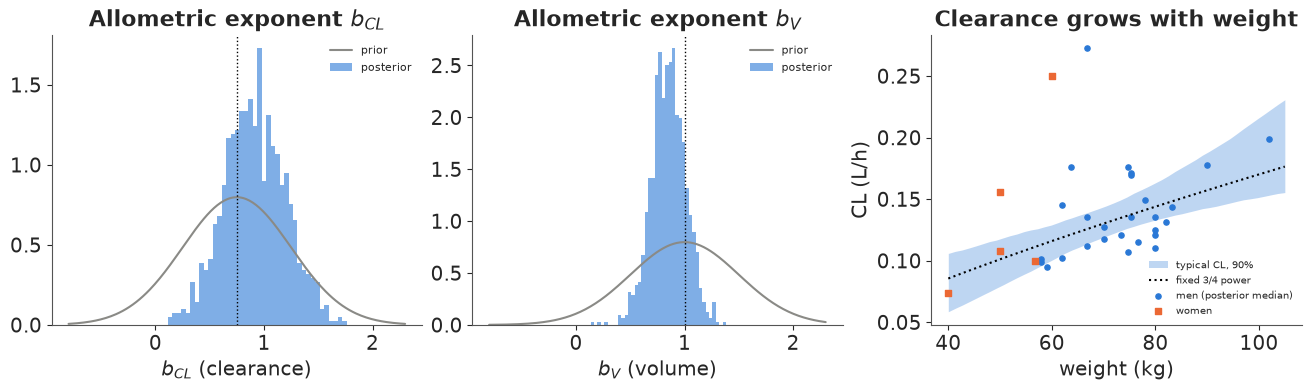

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
xx = np.linspace(-0.8, 2.3, 200)
for ax, draws, mu0, lab in [(axes[0], b_cl, 0.75, "$b_{CL}$ (clearance)"), (axes[1], b_v, 1.0, "$b_V$ (volume)")]:
    ax.plot(xx, norm.pdf(xx, mu0, 0.5), color=GREY, label="prior")
    ax.hist(draws, bins=40, density=True, color=BLUE, alpha=0.6, label="posterior")
    ax.axvline(mu0, color="k", ls=":", lw=1)
    ax.set(xlabel=lab, title=f"Allometric exponent {lab.split()[0]}")
    ax.legend(fontsize=8)
wgrid = np.linspace(40, 105, 50)
cl_curve = np.exp(ew["th_CL"].values[:, None] + b_cl[:, None] * np.log(wgrid / 70))
axes[2].fill_between(wgrid, *np.quantile(cl_curve, [0.05, 0.95], axis=0), color=BLUE, alpha=0.3, lw=0,
                     label="typical CL, 90%")
axes[2].plot(wgrid, np.median(np.exp(ew["th_CL"].values)) * (wgrid / 70) ** 0.75, "k:", label="fixed 3/4 power")
CLw_med = np.median(ew["CL"].values, axis=1)
axes[2].scatter(wt[female == 0], CLw_med[female == 0], s=14, color=BLUE, label="men (posterior median)")
axes[2].scatter(wt[female == 1], CLw_med[female == 1], s=18, color=ORANGE, marker="s", label="women")
axes[2].set(xlabel="weight (kg)", ylabel="CL (L/h)", title="Clearance grows with weight")
axes[2].legend(fontsize=7);

Now all chains agree (r_hat at most 1.02, lag time 0.87 h). Warfarin's typical clearance is
0.13 L/h and volume 7.9 L for a 70 kg man, a half-life of about 42 hours. The data do not
narrow the exponents much: 32 subjects cannot distinguish a 3/4 power from a linear one for
clearance ($b_{CL}$ 90% interval 0.46-1.39; $b_V$ 0.60-1.11). That is the common experience
in small studies, and why many analyses **fix** the exponents at 3/4 and 1 instead of
estimating them. The practical question behind it has a more useful answer: under mg/kg
dosing, exposure (AUC = dose / CL) scales as $\mathrm{wt}^{1 - b_{CL}}$, so a 100 kg patient gets
about the same exposure as a 50 kg one (ratio 1.06, 90% interval 0.77-1.46), rather than
twice as much as with a flat dose. The five women have a somewhat higher clearance for their
weight (log effect 0.25, 90% interval 0.01-0.50), too few to rely on.

**Visual predictive check.** The workhorse check in population PK: simulate the whole study
again, with new subjects drawn from the population (same doses and weights), and compare the
10th, 50th and 90th percentiles of the simulated data at each sampling time with those of the
real data. A good model puts the observed percentiles inside the simulated bands.

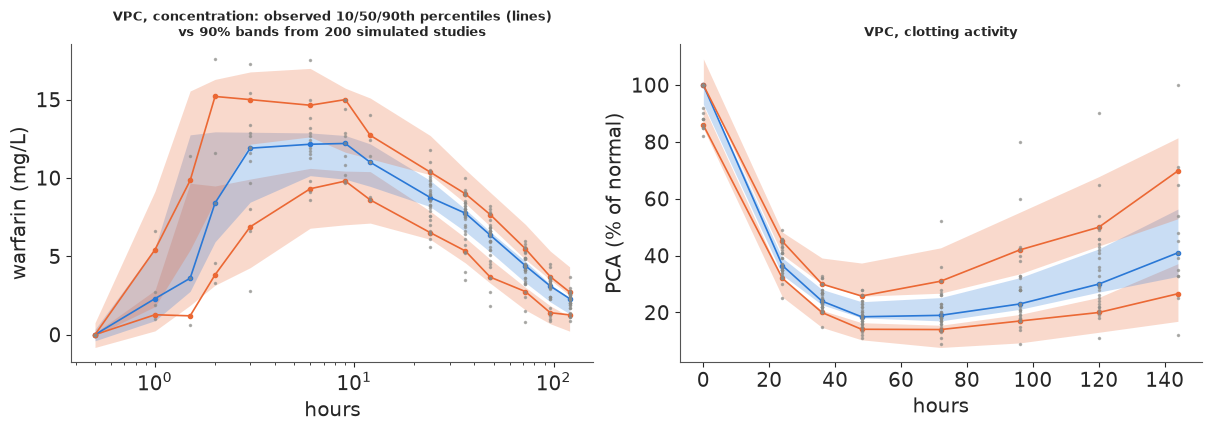

In [23]:
def simulate_warfarin(ew, n_rep=200, seed=1):
    """Replicate the study with NEW subjects (same covariates and doses): returns PK and PD data."""
    rs = np.random.default_rng(seed)
    idx = rs.choice(ew.sizes["sample"], n_rep)
    sds = ew["Lpk_stds"].values[:, idx]
    cor = ew["Lpk_corr"].values[:, :, idx]
    out_pk, out_pd = [], []
    for j, d_ in enumerate(idx):
        cv = np.outer(sds[:, j], sds[:, j]) * cor[:, :, j]
        e = rs.multivariate_normal(np.zeros(3), cv, size=Sw)
        g = {k: ew[k].values[d_] for k in ["th_CL", "th_V", "th_ka", "b_CL", "b_V", "beta_female_CL", "tlag",
                                          "sig_prop", "sig_add", "sig_pd"]}
        CL_ = np.exp(g["th_CL"] + g["b_CL"] * lwt + g["beta_female_CL"] * female + e[:, 0])
        V_ = np.exp(g["th_V"] + g["b_V"] * lwt + e[:, 1])
        ka_ = CL_ / V_ + np.exp(g["th_ka"] + e[:, 2])
        c_ = conc_np(CL_[pk_i], V_[pk_i], ka_[pk_i], np.maximum(pk_t - g["tlag"], 0), dose_w[pk_i])
        out_pk.append(c_ + rs.normal(size=c_.shape) * np.sqrt((g["sig_prop"] * c_) ** 2 + g["sig_add"] ** 2))
        pdp_ = np.exp(ew["mu_pd"].values[:, d_] + rs.normal(size=(Sw, 3)) * ew["sd_pd"].values[:, d_])
        cg = conc_np(CL_[:, None], V_[:, None], ka_[:, None], np.maximum(grid - g["tlag"], 0), dose_w[:, None])
        inh = cg / (pdp_[:, 1:2] + cg)
        kern_ = np.exp(-pdp_[:, 2, None, None] * lag_pos[None]) * trap[None]
        resp_ = pdp_[:, 0:1] * (1 - pdp_[:, 2:3] * (kern_ * inh[:, None, :]).sum(-1))
        out_pd.append(resp_[pd_i, pd_ti] + rs.normal(size=len(pd_i)) * g["sig_pd"])
    return np.array(out_pk), np.array(out_pd)


sim_pk, sim_pd = simulate_warfarin(ew)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, tt_, yy, sim, lab in [(axes[0], pk_t, pk_y, sim_pk, "warfarin (mg/L)"),
                              (axes[1], pd_t, pd_y, sim_pd, "PCA (% of normal)")]:
    bins = np.unique(tt_)
    for qq, col in [(0.1, ORANGE), (0.5, BLUE), (0.9, ORANGE)]:
        sim_q = np.array([np.quantile(sim[:, tt_ == b], qq, axis=1) for b in bins])  # (bins, rep)
        ax.fill_between(bins, *np.quantile(sim_q, [0.05, 0.95], axis=1), color=col, alpha=0.25, lw=0)
        ax.plot(bins, [np.quantile(yy[tt_ == b], qq) for b in bins], "o-", color=col, ms=3, lw=1.2)
    ax.plot(tt_, yy, ".", color=GREY, ms=3, alpha=0.6)
    ax.set(xlabel="hours", ylabel=lab)
axes[0].set_title("VPC, concentration: observed 10/50/90th percentiles (lines)\nvs 90% bands from 200 simulated studies",
                  fontsize=9)
axes[1].set_title("VPC, clotting activity", fontsize=9)
axes[0].set_xscale("log");

Most observed percentiles run inside the simulated bands, for concentrations and for clotting
activity: the fall to a nadir around 48 hours, its depth and the spread between people. Two
places sit at the edge. The observed 90th percentile of concentration between 2 and 9 hours
(about 15 mg/L) is at the top of its band: a few subjects peak higher than the model's
population expects (these early bins hold only 3-14 subjects each). And during the recovery,
from 96 hours on, the observed median PCA is at the lower edge of its band: the typical patient
recovers a little more slowly than a single turnover rate predicts, a hint that the model's
purely indirect response misses some delay (Holford's warfarin models add an effect
compartment). The turnover half-life of the clotting factors, about 13 hours, and a typical
$C_{50}$ near 1.2 mg/L describe how a drug with a 42-hour half-life produces a 2-day dip.

## 8 · Bayesian therapeutic drug monitoring: two samples, validated on every subject

Back to theophylline and the clinical question. A new patient starts treatment. Before any
blood test, all we know is that they come from the population: their clearance could be
anywhere in a band of roughly ±45%. **Therapeutic drug monitoring** (TDM) takes one or two blood samples
and asks what they say about *this* patient. The Bayesian version is exactly the hierarchical
model: add the patient as one more subject with two observations, and their posterior combines
the population (as the prior) with their own samples.

We can test how well this works on real people. For each theophylline subject in turn, we fit
the model to the **other 11 subjects plus only two of this subject's samples** (the ones nearest
7 h and 24 h, a mid-profile and a late sample), and predict the subject's **other 9 samples**,
which the model never saw. The same fit also carries a "ghost" subject with no data at all,
whose predictions are the population-only forecast. One compiled model serves all twelve fits:
the likelihood is weighted by a 0/1 mask in a `pm.Data`, which nutpie swaps without recompiling.

In [24]:
m_tdm = build_theoph(mask=True, ghost=True)
compiled_tdm = nutpie.compile_pymc_model(m_tdm)
TDM_TIMES = (7.0, 24.0)
tdm = {}
t0 = time.perf_counter()
for k in range(S):
    rows = np.where(sid == k)[0]
    keep = rows[[np.argmin(np.abs(t_obs[rows] - tt)) for tt in TDM_TIMES]]
    w = np.ones(len(y_obs))
    w[rows] = 0.0
    w[keep] = 1.0
    tr = nutpie.sample(compiled_tdm.with_data(w=w), seed=RANDOM_SEED + k, progress_bar=False)
    ex = az.extract(tr, var_names=["CL", "V", "ka", "sig_prop", "sig_add"])
    tdm[k] = {"keep": keep, "held": np.setdiff1d(rows, keep),
              "div": int(tr.sample_stats["diverging"].sum()),
              "rhat": float(az.rhat(tr.posterior["CL"]).max()),
              **{f"{v}_ind": ex[v].values[k] for v in ["CL", "V", "ka"]},
              **{f"{v}_pop": ex[v].values[S] for v in ["CL", "V", "ka"]},
              "sig_prop": ex["sig_prop"].values, "sig_add": ex["sig_add"].values}
    del tr, ex
print(f"12 held-out fits in {time.perf_counter() - t0:.0f} s; divergences per fit: "
      f"{[tdm[k]['div'] for k in range(S)]}; worst r_hat of CL: {max(tdm[k]['rhat'] for k in range(S)):.3f}")

12 held-out fits in 15 s; divergences per fit: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]; worst r_hat of CL: 1.003


In [25]:
rows_out = []
for k in range(S):
    held = tdm[k]["held"]
    for kind in ("pop", "ind"):
        cur = conc_np(tdm[k][f"CL_{kind}"][:, None], tdm[k][f"V_{kind}"][:, None], tdm[k][f"ka_{kind}"][:, None],
                      t_obs[held], dose_kg[k], c_pre[k])
        sdv = np.sqrt((tdm[k]["sig_prop"][:, None] * cur) ** 2 + tdm[k]["sig_add"][:, None] ** 2)
        yp = cur + rng.normal(size=cur.shape) * sdv
        lo, hi = np.quantile(yp, [0.05, 0.95], axis=0)
        rows_out.append({"subject": k + 1, "forecast": {"pop": "population only", "ind": "after 2 samples"}[kind],
                         "abs error (mg/L)": np.abs(np.median(yp, axis=0) - y_obs[held]).mean(),
                         "abs error after 4 h": np.abs(np.median(yp, axis=0) - y_obs[held])[t_obs[held] > 4].mean(),
                         "90% interval width": (hi - lo).mean(),
                         "coverage of 90% interval": ((y_obs[held] >= lo) & (y_obs[held] <= hi)).mean(),
                         "CL median": np.median(tdm[k][f"CL_{kind}"]),
                         "CL 90% width": np.diff(np.quantile(tdm[k][f"CL_{kind}"], [0.05, 0.95]))[0]})
val = pd.DataFrame(rows_out)
val.groupby("forecast")[["abs error (mg/L)", "abs error after 4 h", "90% interval width", "coverage of 90% interval",
                         "CL 90% width"]].mean().round(3)

,abs error (mg/L),abs error after 4 h,90% interval width,coverage of 90% interval,CL 90% width
forecast,,,,,
after 2 samples,1.105,0.417,5.094,0.948,0.021
population only,1.337,0.853,5.976,0.927,0.041


Over the 96 held-out concentrations (8 per subject), the gain depends on the phase. **After 4
hours**, the elimination phase that the two samples speak to, the average prediction error
halves (0.85 to 0.42 mg/L). Over all held-out samples it falls only from 1.34 to 1.11 mg/L,
because the early, absorption-phase samples are dominated by the absorption rate, which varies
a lot between people and which samples at 7 and 24 h say almost nothing about. The 90%
prediction intervals cover 93-95% of what was later measured in both cases, so they are honest
(slightly wide). The 90% width of each patient's clearance, the number that decides the
maintenance dose, halves (0.041 to 0.021 L/h/kg). These are out-of-sample numbers: each
subject's other eight samples were never used.

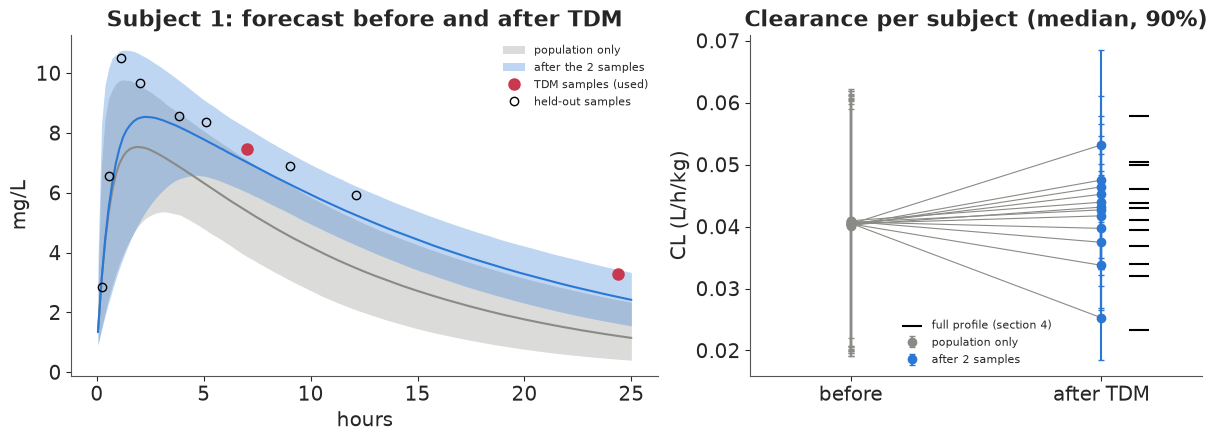

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), width_ratios=[1.3, 1])
k_show = 0  # subject 1: the slowest clearance in the study
held, keep = tdm[k_show]["held"], tdm[k_show]["keep"]
tg = np.linspace(0.05, 25, 150)
for kind, col, lab in [("pop", GREY, "population only"), ("ind", BLUE, "after the 2 samples")]:
    cur = conc_np(tdm[k_show][f"CL_{kind}"][:, None], tdm[k_show][f"V_{kind}"][:, None],
                  tdm[k_show][f"ka_{kind}"][:, None], tg, dose_kg[k_show], c_pre[k_show])
    axes[0].fill_between(tg, *np.quantile(cur, [0.05, 0.95], axis=0), color=col, alpha=0.3, lw=0, label=lab)
    axes[0].plot(tg, np.median(cur, axis=0), color=col, lw=1.5)
axes[0].plot(t_obs[keep], y_obs[keep], "o", color=RED, ms=8, label="TDM samples (used)")
axes[0].plot(t_obs[held], y_obs[held], "o", mfc="none", color="k", ms=6, label="held-out samples")
axes[0].set(xlabel="hours", ylabel="mg/L", title=f"Subject {k_show + 1}: forecast before and after TDM")
axes[0].legend(fontsize=8)
v_ = val.pivot(index="subject", columns="forecast", values="CL median")
w_ = val.pivot(index="subject", columns="forecast", values="CL 90% width")
full_cl = np.median(CLd, axis=1)
for kk in range(S):
    axes[1].plot([0, 1], [v_.loc[kk + 1, "population only"], v_.loc[kk + 1, "after 2 samples"]],
                 color=GREY, lw=0.8)
axes[1].errorbar(np.zeros(S), v_["population only"], yerr=w_["population only"] / 2, fmt="o", color=GREY,
                 capsize=2, label="population only")
axes[1].errorbar(np.ones(S), v_["after 2 samples"], yerr=w_["after 2 samples"] / 2, fmt="o", color=BLUE,
                 capsize=2, label="after 2 samples")
axes[1].scatter(np.full(S, 1.15), full_cl, marker="_", s=200, color="k", label="full profile (section 4)")
axes[1].set(xticks=[0, 1], xticklabels=["before", "after TDM"], xlim=(-0.4, 1.4), ylabel="CL (L/h/kg)",
            title="Clearance per subject (median, 90%)")
axes[1].legend(fontsize=8);

Subject 1 clears theophylline more slowly than anyone else in the study. The population forecast
(grey) falls off too fast; two samples pull the individual forecast (blue) through the held-out
points after 2 hours, though the sharp early peak is still under-predicted. On the right, every
subject's clearance moves from the shared population guess towards the value their full
profile gives (black ticks), with intervals about half as wide.

## 9 · The decision: which regimen for this patient?

Subject 1 weighs 79.6 kg. Suppose they now start **regular** oral theophylline and we must pick
a dose and interval. The goal is a steady-state concentration that stays inside 10-20 mg/L all
through the dosing interval: above 10 for effect, below 20 to avoid nausea, arrhythmias and
seizures. Under repeated dosing every $\tau$ hours the steady-state profile follows from
superposition of the single-dose solution, again in closed form:

$$C_{ss}(t) = \frac{D\,k_a}{V\,(k_a - k_e)}\left[\frac{e^{-k_e t}}{1 - e^{-k_e\tau}} -
\frac{e^{-k_a t}}{1 - e^{-k_a\tau}}\right], \qquad 0 \le t < \tau.$$

It is linear in the dose $D$, so we compute each draw's unit-dose peak and trough once and scale.
For each candidate regimen we report the **probability of target attainment** (PTA: the whole
interval inside 10-20 mg/L) and the probability that the peak exceeds 20 mg/L, under three
states of knowledge: the population only, the posterior after the 2 TDM samples, and (as a
reference the clinic would not have) the full profile, all 10 post-dose samples, from section 4.

In [27]:
def peak_trough_unit(CL, V, ka, wt_kg, tau, n_t=121):
    """Steady-state peak and trough per mg of dose every tau hours (draw arrays in, L/kg units)."""
    tt_ = np.linspace(0, tau, n_t)
    ke = CL / V
    pref = ka / (V * wt_kg * (ka - ke))
    css = pref[:, None] * (np.exp(-ke[:, None] * tt_) / (1 - np.exp(-ke[:, None] * tau))
                           - np.exp(-ka[:, None] * tt_) / (1 - np.exp(-ka[:, None] * tau)))
    return css.max(axis=1), css.min(axis=1)


wt_1 = wt_th[k_show]
for nm_, CL_ in [("population only", tdm[k_show]["CL_pop"]), ("after 2 samples", tdm[k_show]["CL_ind"])]:
    V_ = tdm[k_show]["V_pop" if nm_ == "population only" else "V_ind"]
    print(f"subject 1, {nm_}: half-life {q(np.log(2) * V_ / CL_)} h")
knowledge = {
    "population only": (tdm[k_show]["CL_pop"], tdm[k_show]["V_pop"], tdm[k_show]["ka_pop"]),
    "after 2 samples": (tdm[k_show]["CL_ind"], tdm[k_show]["V_ind"], tdm[k_show]["ka_ind"]),
    "full profile": (CLd[k_show], Vd[k_show], kad[k_show]),
}
doses = np.arange(50, 1001, 25)
taus = [6, 8, 12]
pta = {}
for name, (CL_, V_, ka_) in knowledge.items():
    for tau in taus:
        pk_, tr_ = peak_trough_unit(CL_, V_, ka_, wt_1, tau)
        ok = (doses[:, None] * tr_ >= 10) & (doses[:, None] * pk_ <= 20)
        pta[(name, tau)] = {"pta": ok.mean(axis=1), "tox": (doses[:, None] * pk_ > 20).mean(axis=1),
                            "low": (doses[:, None] * tr_ < 10).mean(axis=1)}

rows = []
for (name, tau), res in pta.items():
    i = np.argmax(res["pta"])
    rows.append({"knowledge": name, "every (h)": tau, "best dose (mg)": doses[i], "mg/day": doses[i] * 24 // tau,
                 "PTA": res["pta"][i], "P(peak > 20)": res["tox"][i], "P(trough < 10)": res["low"][i]})
best = pd.DataFrame(rows).set_index(["knowledge", "every (h)"])
best.round(3)

subject 1, population only: half-life [ 5.257  7.959 12.001] h
subject 1, after 2 samples: half-life [ 8.436 11.352 15.736] h


best dose (mg)  mg/day    PTA  P(peak > 20)  \
knowledge       every (h)                                                
population only 6                     275    1100  0.504         0.183   
                8                     350    1050  0.324         0.192   
                12                    500    1000  0.062         0.291   
after 2 samples 6                     175     700  0.838         0.064   
                8                     225     675  0.706         0.067   
                12                    350     700  0.346         0.259   
full profile    6                     175     700  0.925         0.069   
                8                     225     675  0.878         0.071   
                12                    325     650  0.456         0.149   

                           P(trough < 10)  
knowledge       every (h)                  
population only 6                   0.312  
                8                   0.485  
                12                  0.741  
after 2 samples 6                   0.098  
                8                   0.227  
                12                  0.406  
full profile    6                   0.006  
                8                   0.051  
                12                  0.395

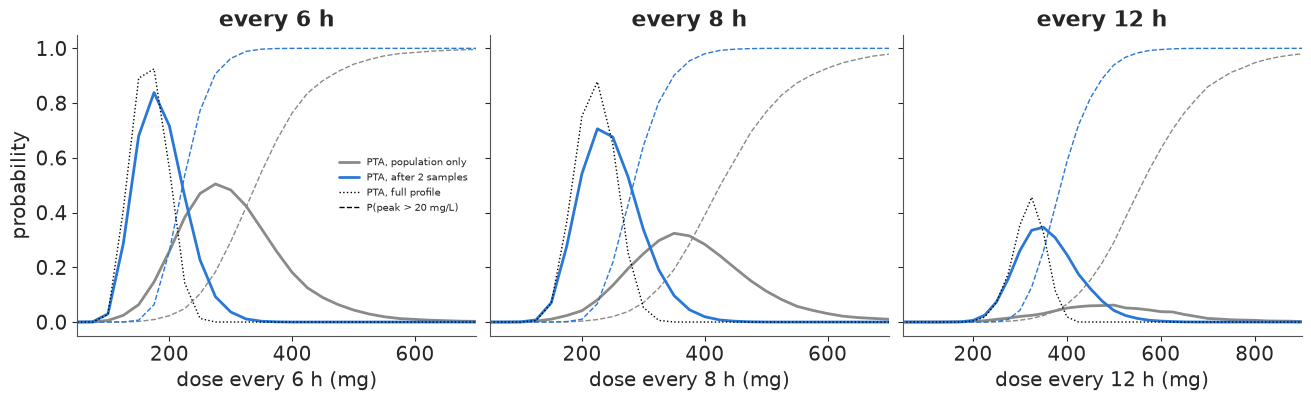

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), sharey=True)
for ax, tau in zip(axes, taus):
    for (name, col) in [("population only", GREY), ("after 2 samples", BLUE), ("full profile", "k")]:
        res = pta[(name, tau)]
        ax.plot(doses, res["pta"], color=col, lw=2 if name != "full profile" else 1,
                ls="-" if name != "full profile" else ":", label=f"PTA, {name}")
        if name != "full profile":
            ax.plot(doses, res["tox"], color=col, lw=1, ls="--")
    ax.set(xlabel=f"dose every {tau} h (mg)", title=f"every {tau} h", xlim=(50, 900 if tau == 12 else 700))
axes[0].set_ylabel("probability")
axes[0].plot([], [], color="k", ls="--", lw=1, label="P(peak > 20 mg/L)")
axes[0].legend(fontsize=7);

Three things stand out.

- **Population dosing is a gamble.** With only the population to go on, the best regimen is
  275 mg every 6 hours, and even that reaches the target with probability 0.50: the
  between-person spread in clearance is wider than the window allows.
- **Two samples change the dose.** The TDM samples say subject 1's half-life is about 11 hours
  (90% interval 8-16), not the population's 8, so the best dose drops to 175 mg every 6 hours
  (or 225 mg every 8), with a probability of target attainment of 0.84 (0.71). That is the same
  dose the full profile recommends.
- **The interval matters.** Over a 12-hour interval the concentration falls by about the 2-fold
  width of the 10-20 window, so even with full knowledge of this patient the best 12-hourly dose
  keeps the whole interval in range with probability below one half (0.35 after TDM, 0.46 with
  the full profile). That is why immediate-release theophylline is given every 6-8 hours, and
  sustained-release products exist.

The final regimen for subject 1, as the clinic would see it:

population-based 275 mg q6h for this patient: P(peak > 20) = 0.91, PTA = 0.09
TDM-based 175 mg q6h: P(peak > 20) = 0.06, PTA = 0.84


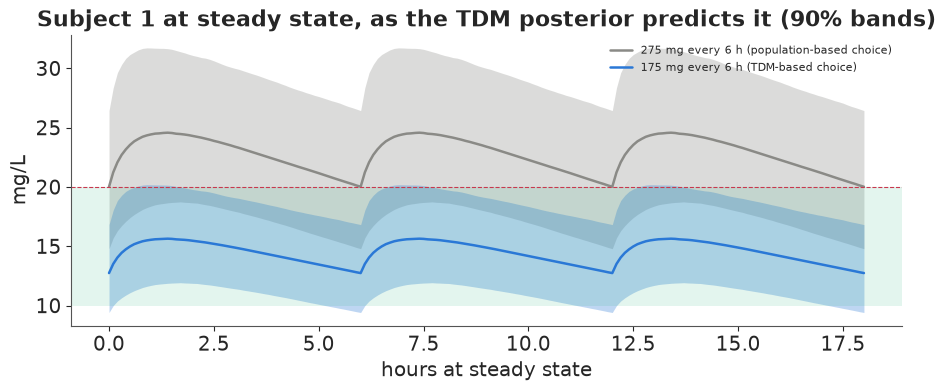

In [29]:
tau_c = 6
name = "after 2 samples"
d_c = best.loc[(name, tau_c), "best dose (mg)"]
d_pop = best.loc[("population only", tau_c), "best dose (mg)"]
fig, ax = plt.subplots(figsize=(9, 3.8))
t_ss = np.linspace(0, 3 * tau_c, 181)
for nm, dd, col in [("population only", d_pop, GREY), (name, d_c, BLUE)]:
    CL_, V_, ka_ = knowledge[name]  # the patient as we now believe them to be
    ke_ = CL_ / V_
    tm = np.mod(t_ss, tau_c)
    css = dd / wt_1 * ka_[:, None] / (V_[:, None] * (ka_ - ke_)[:, None]) * (
        np.exp(-ke_[:, None] * tm) / (1 - np.exp(-ke_[:, None] * tau_c))
        - np.exp(-ka_[:, None] * tm) / (1 - np.exp(-ka_[:, None] * tau_c)))
    ax.fill_between(t_ss, *np.quantile(css, [0.05, 0.95], axis=0), color=col, alpha=0.3, lw=0)
    ax.plot(t_ss, np.median(css, axis=0), color=col, lw=1.8,
            label=f"{dd} mg every {tau_c} h ({'population' if nm == 'population only' else 'TDM'}-based choice)")
ax.axhspan(10, 20, color=AQUA, alpha=0.12, lw=0)
ax.axhline(20, color=RED, lw=0.8, ls="--")
ax.set(xlabel="hours at steady state", ylabel="mg/L",
       title="Subject 1 at steady state, as the TDM posterior predicts it (90% bands)")
ax.legend(fontsize=8)
print(f"population-based {d_pop} mg q{tau_c}h for this patient: P(peak > 20) = "
      f"{pta[(name, tau_c)]['tox'][doses == d_pop][0]:.2f}, PTA = {pta[(name, tau_c)]['pta'][doses == d_pop][0]:.2f}")
print(f"TDM-based {d_c} mg q{tau_c}h: P(peak > 20) = {pta[(name, tau_c)]['tox'][doses == d_c][0]:.2f}, "
      f"PTA = {pta[(name, tau_c)]['pta'][doses == d_c][0]:.2f}");

Evaluated with what the two samples revealed about this patient, the population-based dose
(275 mg every 6 hours, 1,100 mg a day) would give peaks above 20 mg/L with probability 0.91 and
keep the whole interval in range with probability 0.09. The TDM-based 175 mg every 6 hours
brings those to 0.06 and 0.84. Two caveats: the steady-state predictions assume linear kinetics,
and theophylline's elimination is known to **saturate** at high concentrations (Michaelis-Menten
kinetics), so concentrations near the top of the window rise more than proportionally with dose;
and the posterior is for one single-dose study, not a steady-state one. A real TDM service would
confirm with a steady-state trough sample.

## Summary

- The **one-compartment oral model** has a closed-form solution; written with `expm1` it is
  stable on both sides of $k_a = k_e$ (section 1).
- **Flip-flop**: after one oral dose, $(k_a, k_e, V)$ and $(k_e, k_a, V k_e/k_a)$ give identical
  curves; clearance is identified, volume and absorption rate are not (section 2). Chains
  started in both basins each stayed in their own, fitting equally well with r_hat far above 1;
  a single run starting in one basin would have looked healthy.
- An **ordering** $k_a = k_e + e^\eta$ removes the mirror mode but assumes fast absorption (wrong
  for sustained-release products); a **physiological prior** on the volume removes it without
  that assumption (section 3). Together with textbook priors the population model sampled cleanly
  and gave clearance 0.040 L/h/kg, volume 0.46 L/kg, half-life about 8 h, 27% between-subject CV
  in clearance (section 4).
- LOO could not separate additive from combined error; normalised prediction errors showed no
  drift, but a wider spread in the absorption phase than later (section 5).
- On **warfarin**, estimated allometric exponents were consistent with 3/4 and 1 but wide; the
  decision-relevant consequence, that mg/kg dosing gives similar exposure across weights, was
  more useful. Four zero concentrations were treated as **censored**. A **lag time** created a
  spurious mode (one chain, r_hat 1.13, no divergences) because samples before the lag pass no
  gradient to it; starting the lag inside the early samples fixed it (sections 6-7).
- A **turnover model**, solved as a convolution of the inhibition curve (no ODE solver), fitted
  jointly with PK, reproduced the 2-day dip and recovery of clotting activity in a **visual
  predictive check** (section 7).
- **Bayesian TDM**, validated on each theophylline subject's held-out samples: two samples
  halved the prediction error after 4 hours and the width of each clearance posterior, with
  93-95% coverage of 90% intervals; the absorption phase stayed hard to predict (section 8).
- For the slowest-clearing patient, two samples lowered the chosen dose from 275 to 175 mg
  every 6 hours and raised the probability of staying in 10-20 mg/L from 0.09 (population dose,
  judged with the TDM posterior) to 0.84; 12-hourly immediate-release dosing cannot reliably
  keep the whole interval in range (section 9).

## Try it yourself

1. **Saturable elimination.** Theophylline's elimination is Michaelis-Menten:
   $dC/dt = -V_\max C / (K_m + C)$ plus absorption. There is no closed form for oral dosing:
   solve it with a fixed-step RK4 in `pytensor.scan` (or `diffrax` through `pytensor.wrap_jax`)
   and fit it. Do 25 hours of single-dose data identify $K_m$? How does the section 9 decision
   change if $K_m$ is 20 mg/L?
2. **Sparse sampling and the mirror world.** Refit the vague, unordered model of section 2 on
   the warfarin data (where 19 of 32 subjects have no absorption-phase samples) with default
   nutpie starts, several seeds. How often does a run land in the mirror mode, and would you
   have noticed from one run's diagnostics?
3. **Which samples?** Section 8 used samples near 7 h and 24 h. Repeat the validation with
   samples at 1 h and 4 h, or with a single 12 h sample. Which design shrinks the clearance
   posterior most, and which gives the best section 9 decision? (This is optimal design for TDM:
   the expected posterior variance of CL under the population predictive is a cheap criterion.)